# **Neural Networks Based on Differential Equations: From Physics-Informed Neural Networks to Neural ODEs**

### **Tutorial @ The Machine Learning and Principles and Practice of Knowledge Discovery in Databases - ECML PKDD 2025**

#### **Cecília Coelho and Luís Ferrás**

#### **Go to [website][Website]**

[Website]: https://nnsdestutorial.github.io/

# --------------------------------------------------------

# Differential Equations Basics (Part I)

#### Numerical solution of a simple ODE using the explicit Euler method


The differential equation $\dfrac{df(t)}{dt}=e^{−t}$ with initial condition $f(0)=−1$ has the exact solution $f(t)=−e^{−t}$. Approximate the solution to this initial value problem between 0 and 1 in increments of 0.1 using the **Explicit Euler Formula**. Plot the difference between the approximated solution and the exact solution.



Play with the **solver**, **model parameters** and the **number of mesh elements**.

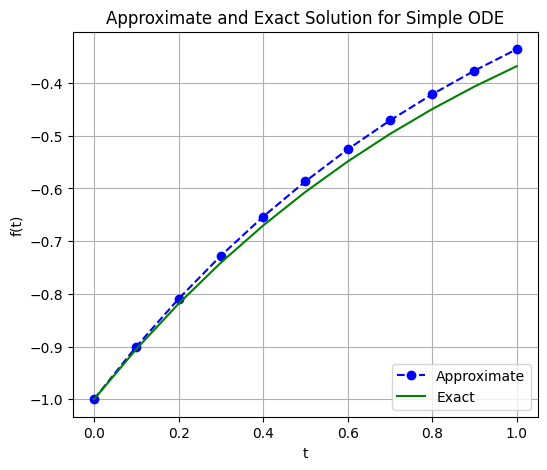

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#plt.style.use('seaborn-poster')
%matplotlib inline

# Define parameters
f = lambda t, s: np.exp(-t) # ODE
h = 0.1 # Step size
t = np.arange(0, 1 + h, h) # Numerical grid
s0 = -1 # Initial Condition

# Explicit Euler Method
s = np.zeros(len(t))
s[0] = s0

for i in range(0, len(t) - 1):
    s[i + 1] = s[i] + h*f(t[i], s[i])

plt.figure(figsize = (6, 5))
plt.plot(t, s, 'bo--', label='Approximate')
plt.plot(t, -np.exp(-t), 'g', label='Exact')
plt.title('Approximate and Exact Solution \
for Simple ODE')
plt.xlabel('t')
plt.ylabel('f(t)')
plt.grid()
plt.legend(loc='lower right')
plt.show()

## Differential Equations Basics (Part II)

#### Logistic Growth of a Population of Organisms

Consider a population of organisms that follows a logistic growth. The population size $P(t)$ at time $t$ is governed by the following differential equation:
            \begin{equation}
             P'(t) = r P(t) \left(1 - \frac{P(t)}{K}\right), \quad P(t_0) = 100,
            \end{equation}
            where $r$ is the growth rate, and $K$ is the carrying capacity of the environment. Consider $r=0.1, K=1000$. Also, consider a mesh of 200 points.



Play with the **solver**, **model parameters** and the **number of mesh elements**.

##### First, try to implement $P'(t) = r P(t)$

In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

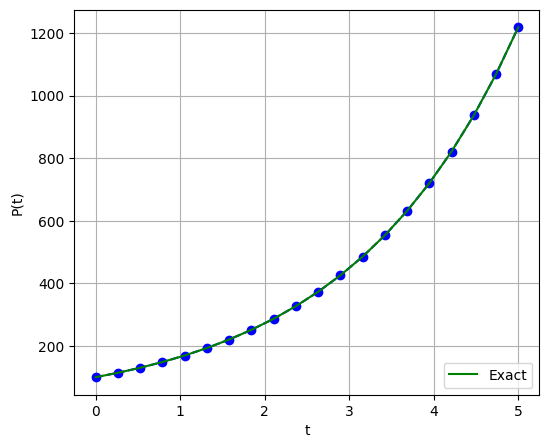

In [3]:
r = 0.5
y0 = [100]
t = np.linspace(0, 5, 20)

def ODE(t, y):
    return r * y

sol = solve_ivp(ODE, [0, 5], y0, t_eval=t)

plt.figure(figsize = (6, 5))
plt.plot(sol.t.T, sol.y.T,'bo--')
plt.plot(t, y0*np.exp(r*t), 'g', label='Exact')
plt.xlabel('t')
plt.ylabel('P(t)')
plt.grid()
plt.legend(loc='lower right')
plt.show()

##### Now try to implement $P'(t) = r P(t) \left(1 - \frac{P(t)}{K}\right)$

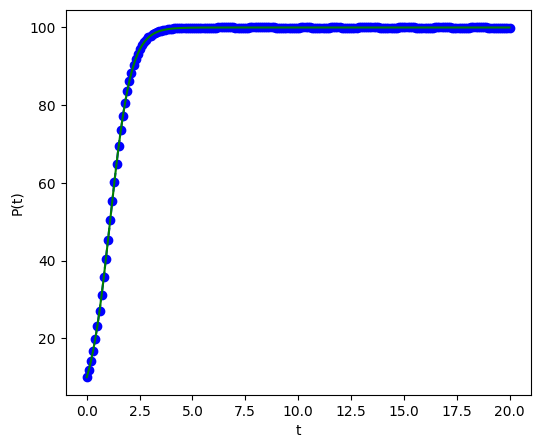

In [4]:
r = 2
K = 100
y0 = 10
t = np.linspace(0, 20, 200)

def ODE(t, y):
    return r * y * (1- y/K)

sol = solve_ivp(ODE, [0, 20], [y0], t_eval=t)

plt.figure(figsize = (6, 5))
plt.plot(sol.t.T, sol.y.T,'bo--')
plt.plot(t, (K*y0*np.exp(r*t))/(K+y0*(np.exp(r*t)-1)), 'g', label='Exact')
plt.xlabel('t')
plt.ylabel('P(t)')
plt.show()

# --------------------------------------------------------

## Physics-Informed Neural Networks

 Consider the 1D Burger's Equation with Dirichlet boundary conditions and $\lambda_1=1, \lambda_2=\frac{0.01}{\pi}$:
            $$
             \begin{align*}
                    \frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} - \frac{0.01}{\pi} \frac{\partial^2u}{\partial x^2} = 0, \quad x\in [-1,1], t\in [0,1], \\
                    u(0,x) = -\sin(\pi x),\\
                    u(t,-1) = u(t,1) = 0.
                \end{align*}
            $$


In [5]:
!pip install torch
!pip install git+https://github.com/lululxvi/deepxde
!pip install tensorflow

  Cloning https://github.com/lululxvi/deepxde to /tmp/pip-req-build-18kz990u
  Running command git clone --filter=blob:none --quiet https://github.com/lululxvi/deepxde /tmp/pip-req-build-18kz990u
  Resolved https://github.com/lululxvi/deepxde to commit b944422a55894d4d598455df63dc0d47cd8a5d82
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 4.5 MB/s eta 0:00:00
  Created wheel for DeepXDE: filename=deepxde-1.14.1.dev8+gb944422a5-py3-none-any.whl size=195633 sha256=2b11a46b5a248b60aefca8a77aebd782fc8a9b52d05cebe965e933593fd52cb1
  Stored in directory: /tmp/pip-ephem-wheel-cache-wjrw3tcj/wheels/ba/8e/f0/5fbffbbb7f30514631a88628e411015969a07da4ecf939b3ab
Successfully built DeepXDE


In [6]:
import deepxde as dde
import matplotlib.pyplot as plt
import numpy as np
from scipy import integrate
import tensorflow as tf
from scipy import integrate
import torch

No backend selected.
Finding available backend...


Using backend: tensorflow.compat.v1
Other supported backends: tensorflow, pytorch, jax, paddle.
paddle supports more examples now and is recommended.
Instructions for updating:
non-resource variables are not supported in the long term


Found tensorflow.compat.v1
Setting the default backend to "tensorflow.compat.v1". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


### Data-driven solutions

**Problem:** *Given fixed model parameters $\lambda$, what can be said about the unknown $u(t, x)$?*
            
PINNs approximate the solution $u(x)$ using a neural network $\hat{u}(x; \boldsymbol{\theta})$, where $\boldsymbol{\theta}$ represents the network parameters. The PINN is trained to fit the data and satisfy the PDE

#### 1D Burger's Equation

**Hands-on**

What happens if we change the number of training points inside the domain? What about in the inital and boundary conditions?

Compiling model...
Building feed-forward neural network...
'build' took 0.066853 s

'compile' took 0.590560 s

Training model...

Step      Train loss                        Test loss                         Test metric
0         [6.79e-01, 2.79e-01, 7.33e-01]    [6.79e-01, 2.79e-01, 7.33e-01]    []  
1000      [4.89e-02, 4.33e-03, 7.31e-02]    [4.89e-02, 4.33e-03, 7.31e-02]    []  
2000      [3.60e-02, 3.22e-04, 5.15e-02]    [3.60e-02, 3.22e-04, 5.15e-02]    []  
3000      [2.94e-02, 9.28e-05, 4.33e-02]    [2.94e-02, 9.28e-05, 4.33e-02]    []  
4000      [1.32e-02, 1.14e-04, 1.20e-02]    [1.32e-02, 1.14e-04, 1.20e-02]    []  
5000      [5.64e-03, 3.89e-05, 5.22e-03]    [5.64e-03, 3.89e-05, 5.22e-03]    []  
6000      [3.59e-03, 2.48e-05, 3.59e-03]    [3.59e-03, 2.48e-05, 3.59e-03]    []  
7000      [2.83e-03, 1.44e-05, 3.16e-03]    [2.83e-03, 1.44e-05, 3.16e-03]    []  
8000      [2.21e-03, 5.12e-06, 2.71e-03]    [2.21e-03, 5.12e-06, 2.71e-03]    []  
9000      [1.98e-03, 5.73e-06, 2.

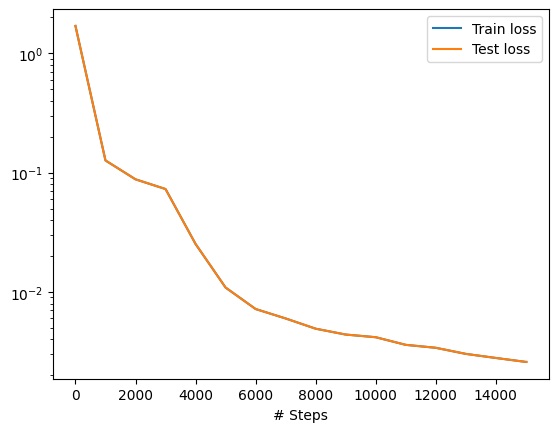

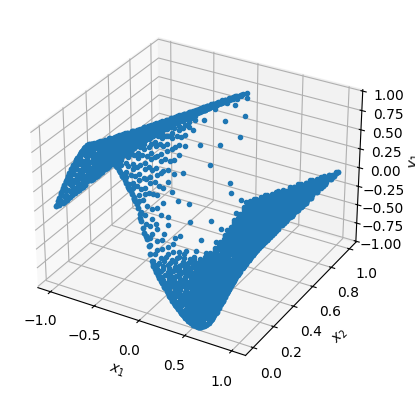

Mean residual: 0.020583965
L2 relative error: 0.054056528541203346


In [7]:
# tensorflow

def gen_testdata():
    data = np.load("Burgers.npz")
    t, x, exact = data["t"], data["x"], data["usol"].T
    xx, tt = np.meshgrid(x, t)
    X = np.vstack((np.ravel(xx), np.ravel(tt))).T
    y = exact.flatten()[:, None]
    return X, y


def pde(x, y):
    dy_x = dde.grad.jacobian(y, x, i=0, j=0)
    dy_t = dde.grad.jacobian(y, x, i=0, j=1)
    dy_xx = dde.grad.hessian(y, x, i=0, j=0)
    return dy_t + y * dy_x - 0.01 / np.pi * dy_xx


geom = dde.geometry.Interval(-1, 1)
timedomain = dde.geometry.TimeDomain(0, 1)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

bc = dde.icbc.DirichletBC(geomtime, lambda x: 0, lambda _, on_boundary: on_boundary)
ic = dde.icbc.IC(
    geomtime, lambda x: -np.sin(np.pi * x[:, 0:1]), lambda _, on_initial: on_initial
)

data = dde.data.TimePDE(
    geomtime, pde, [bc, ic], num_domain=2540, num_boundary=80, num_initial=160
)
net = dde.nn.FNN([2] + [20] * 3 + [1], "tanh", "Glorot normal")
model = dde.Model(data, net)

model.compile("adam", lr=1e-3)
model.train(iterations=15000)
model.compile("L-BFGS")
losshistory, train_state = model.train()
dde.saveplot(losshistory, train_state, issave=True, isplot=True)

X, y_true = gen_testdata()
y_pred = model.predict(X)
f = model.predict(X, operator=pde)
print("Mean residual:", np.mean(np.absolute(f)))
print("L2 relative error:", dde.metrics.l2_relative_error(y_true, y_pred))
np.savetxt("test.dat", np.hstack((X, y_true, y_pred)))

#### Lotka-Volterra

**Hands-on**

Use PINNs to approximate the solution of the following Lotka-Volterra problem to know how the population of rabbits and foxes change over time in a system:
                $$\begin{align*}
                    \dfrac{dr}{dt}=\dfrac{R}{U}(2Ur - 0.04U^2rf), \quad \dfrac{df}{dt}=\dfrac{R}{U}(0.002U^2rf - 1.06Uf), \\
                    r(0)= \dfrac{100}{U}, \quad f(0)=\dfrac{15}{U}
                \end{align*}$$
                with $U=200$ and $R=20$.

Compiling model...
Building feed-forward neural network...
'build' took 0.126334 s

'compile' took 1.209448 s

Training model...

Step      Train loss              Test loss               Test metric
0         [1.38e+02, 4.40e+01]    [1.38e+02, 4.40e+01]    []  
1000      [3.24e+00, 1.23e+00]    [3.15e+00, 1.23e+00]    []  
2000      [2.25e+00, 7.88e-01]    [2.16e+00, 7.82e-01]    []  
3000      [1.70e+00, 6.88e-01]    [1.62e+00, 6.77e-01]    []  
4000      [1.25e+00, 6.28e-01]    [1.18e+00, 6.15e-01]    []  
5000      [7.97e-01, 4.80e-01]    [7.51e-01, 4.67e-01]    []  
6000      [4.64e-01, 3.54e-01]    [4.40e-01, 3.42e-01]    []  
7000      [2.60e-01, 2.99e-01]    [2.47e-01, 2.88e-01]    []  
8000      [1.65e-01, 2.39e-01]    [1.59e-01, 2.30e-01]    []  
9000      [1.18e-01, 1.91e-01]    [1.16e-01, 1.85e-01]    []  
10000     [8.10e-02, 1.54e-01]    [8.01e-02, 1.49e-01]    []  
11000     [6.63e-02, 1.14e-01]    [6.58e-02, 1.11e-01]    []  
12000     [5.29e-02, 9.26e-02]    [5.27e-02,

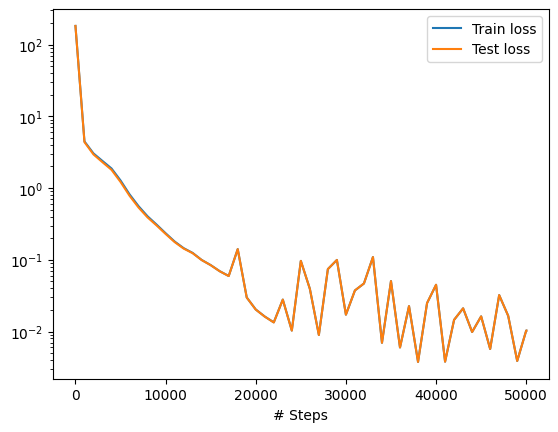

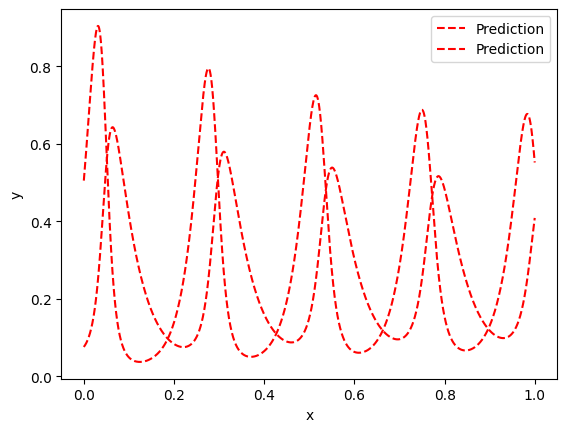

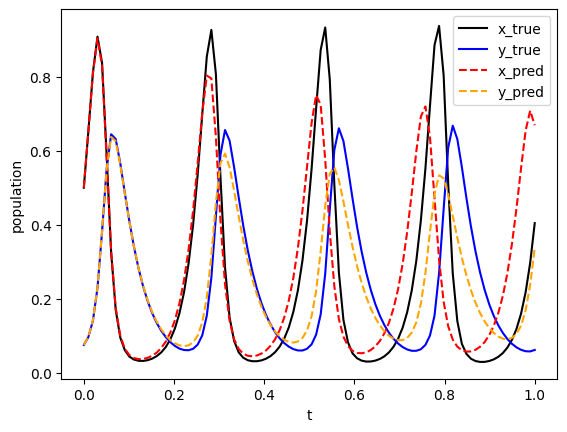

In [10]:
# torch

ub = 200
rb = 20


def func(t, r):
    x, y = r
    dx_t = 1 / ub * rb * (2.0 * ub * x - 0.04 * ub * x * ub * y)
    dy_t = 1 / ub * rb * (0.02 * ub * x * ub * y - 1.06 * ub * y)
    return dx_t, dy_t


def gen_truedata():
    t = np.linspace(0, 1, 100)

    sol = integrate.solve_ivp(func, (0, 10), (100 / ub, 15 / ub), t_eval=t)
    x_true, y_true = sol.y
    x_true = x_true.reshape(100, 1)
    y_true = y_true.reshape(100, 1)

    return x_true, y_true


def ode_system(x, y):
    r = y[:, 0:1]
    p = y[:, 1:2]
    dr_t = dde.grad.jacobian(y, x, i=0)
    dp_t = dde.grad.jacobian(y, x, i=1)

    return [
        dr_t - 1 / ub * rb * (2.0 * ub * r - 0.04 * ub * r * ub * p),
        dp_t - 1 / ub * rb * (0.02 * r * ub * p * ub - 1.06 * p * ub),
    ]

geom = dde.geometry.TimeDomain(0, 1.0)
data = dde.data.PDE(geom, ode_system, [], 3000, 2, num_test=3000)

layer_size = [1] + [64] * 6 + [2]
activation = "tanh"
initializer = "Glorot normal"
net = dde.nn.FNN(layer_size, activation, initializer)


def input_transform(t):
    return tf.concat(
        (
            t,
            tf.sin(t),
            tf.sin(2 * t),
            tf.sin(3 * t),
            tf.sin(4 * t),
            tf.sin(5 * t),
            tf.sin(6 * t),
        ),
        axis=1,
    )


# hard constraints: x(0) = 100, y(0) = 15

def output_transform(t, y):
    y1 = y[:, 0:1]
    y2 = y[:, 1:2]
    return tf.concat([y1 * tf.tanh(t) + 100 / ub, y2 * tf.tanh(t) + 15 / ub], axis=1)

net.apply_feature_transform(input_transform)
net.apply_output_transform(output_transform)
model = dde.Model(data, net)

model.compile("adam", lr=0.001)
losshistory, train_state = model.train(iterations=50000)
model.compile("L-BFGS")
losshistory, train_state = model.train()
dde.saveplot(losshistory, train_state, issave=True, isplot=True)

plt.xlabel("t")
plt.ylabel("population")

t = np.linspace(0, 1, 100)
x_true, y_true = gen_truedata()
plt.plot(t, x_true, color="black", label="x_true")
plt.plot(t, y_true, color="blue", label="y_true")

t = t.reshape(100, 1)
sol_pred = model.predict(t)
x_pred = sol_pred[:, 0:1]
y_pred = sol_pred[:, 1:2]

plt.plot(t, x_pred, color="red", linestyle="dashed", label="x_pred")
plt.plot(t, y_pred, color="orange", linestyle="dashed", label="y_pred")
plt.legend()
plt.show()

### Data-driven discovery

**Problem:** *What are the parameters $\lambda$ that best describe the observed data?*

Again, PINNs approximate the solution $u(x)$ using a neural network $\hat{u}(x; \boldsymbol{\theta})$, where $\boldsymbol{\theta}$ represents the network parameters.

#### Diffusion Equation

**Hands-on**

What happens if we change the number of training points inside the domain? What about in the inital and boundary conditions?

Compiling model...
Building feed-forward neural network...
'build' took 0.078057 s

'compile' took 0.613588 s

Training model...

Step      Train loss                                  Test loss                                   Test metric   
0         [1.47e+01, 1.59e-01, 3.87e-01, 3.28e-01]    [1.69e+01, 1.59e-01, 3.87e-01, 3.28e-01]    [1.08e+00]    
0 [2.00e+00]
1000      [8.24e-03, 2.46e-02, 5.05e-02, 1.78e-02]    [1.04e-02, 2.46e-02, 5.05e-02, 1.78e-02]    [3.98e-01]    
1000 [2.00e+00]
2000      [2.75e-03, 4.56e-03, 1.12e-02, 7.85e-03]    [5.58e-03, 4.56e-03, 1.12e-02, 7.85e-03]    [3.94e-01]    
2000 [1.70e+00]
3000      [7.37e-04, 1.52e-03, 1.36e-03, 4.24e-03]    [3.47e-03, 1.52e-03, 1.36e-03, 4.24e-03]    [2.85e-01]    
3000 [1.43e+00]
4000      [2.17e-04, 4.89e-04, 3.78e-05, 1.44e-03]    [2.25e-03, 4.89e-04, 3.78e-05, 1.44e-03]    [1.60e-01]    
4000 [1.21e+00]
5000      [1.14e-04, 1.57e-04, 6.16e-06, 2.63e-04]    [1.47e-03, 1.57e-04, 6.16e-06, 2.63e-04]    [6.42e-02]    
50

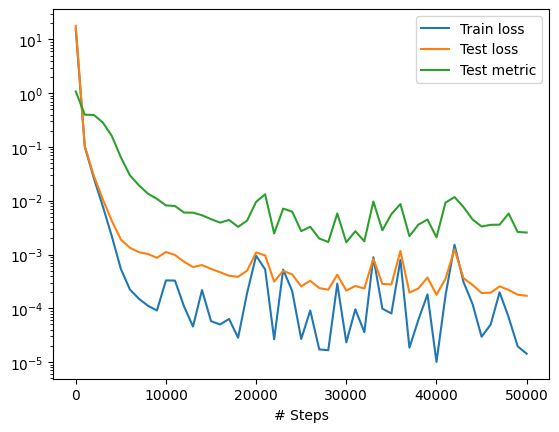

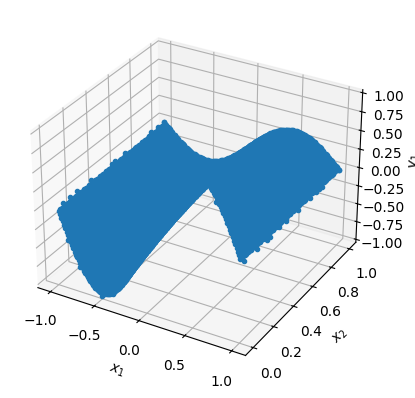

In [12]:
C = dde.Variable(2.0)


def pde(x, y):
    dy_t = dde.grad.jacobian(y, x, i=0, j=1)
    dy_xx = dde.grad.hessian(y, x, i=0, j=0)
    return (
        dy_t
        - C * dy_xx
        + tf.exp(-x[:, 1:])
        * (tf.sin(np.pi * x[:, 0:1]) - np.pi ** 2 * tf.sin(np.pi * x[:, 0:1]))
    )


def func(x):
    return np.sin(np.pi * x[:, 0:1]) * np.exp(-x[:, 1:])


geom = dde.geometry.Interval(-1, 1)
timedomain = dde.geometry.TimeDomain(0, 1)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

bc = dde.icbc.DirichletBC(geomtime, func, lambda _, on_boundary: on_boundary)
ic = dde.icbc.IC(geomtime, func, lambda _, on_initial: on_initial)

observe_x = np.vstack((np.linspace(-1, 1, num=10), np.full((10), 1))).T
observe_y = dde.icbc.PointSetBC(observe_x, func(observe_x), component=0)

data = dde.data.TimePDE(
    geomtime,
    pde,
    [bc, ic, observe_y],
    num_domain=40,
    num_boundary=20,
    num_initial=10,
    anchors=observe_x,
    solution=func,
    num_test=10000,
)

layer_size = [2] + [32] * 3 + [1]
activation = "tanh"
initializer = "Glorot uniform"
net = dde.nn.FNN(layer_size, activation, initializer)

model = dde.Model(data, net)

model.compile(
    "adam", lr=0.001, metrics=["l2 relative error"], external_trainable_variables=C
)
variable = dde.callbacks.VariableValue(C, period=1000)
losshistory, train_state = model.train(iterations=50000, callbacks=[variable])

dde.saveplot(losshistory, train_state, issave=True, isplot=True)

#### Lorenz System

**Hands-on**

Use PINNs to discover $\sigma, \rho, \beta$ for the following Lorenz system:
                $$\begin{align*}
                    \dfrac{dx}{dt}=\sigma(y-x), \quad \dfrac{dy}{dt}=x(\rho-z)-y, \quad \dfrac{dz}{dt}=xy-\beta z, \quad t\in[0,3]\\
                    x(0)=-8, \quad y(0)=7, \quad z(0) = 27.
                \end{align*}$$

Compiling model...
Building feed-forward neural network...
'build' took 0.074549 s

'compile' took 0.775465 s

Training model...

Step      Train loss                                                                                    Test loss                                                                                     Test metric
0         [1.18e-01, 1.18e-01, 2.34e-01, 6.40e+01, 4.90e+01, 7.29e+02, 3.61e+01, 3.92e+01, 2.66e+02]    [1.18e-01, 1.18e-01, 2.34e-01, 6.40e+01, 4.90e+01, 7.29e+02, 3.61e+01, 3.92e+01, 2.66e+02]    []  
1000      [6.29e+00, 2.82e+00, 2.90e+00, 3.04e+01, 1.16e-03, 1.78e+00, 3.30e+01, 7.46e+00, 1.00e+01]    [6.29e+00, 2.82e+00, 2.90e+00, 3.04e+01, 1.16e-03, 1.78e+00, 3.30e+01, 7.46e+00, 1.00e+01]    []  
2000      [9.07e+00, 2.00e+00, 1.39e+00, 1.76e+01, 2.53e-01, 1.68e+00, 3.29e+01, 1.48e+01, 4.54e+00]    [9.07e+00, 2.00e+00, 1.39e+00, 1.76e+01, 2.53e-01, 1.68e+00, 3.29e+01, 1.48e+01, 4.54e+00]    []  
3000      [8.67e+00, 2.04e+00, 9.89e-01, 1.38e+01, 

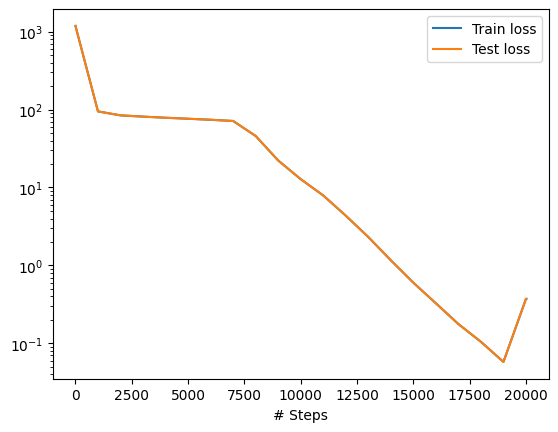

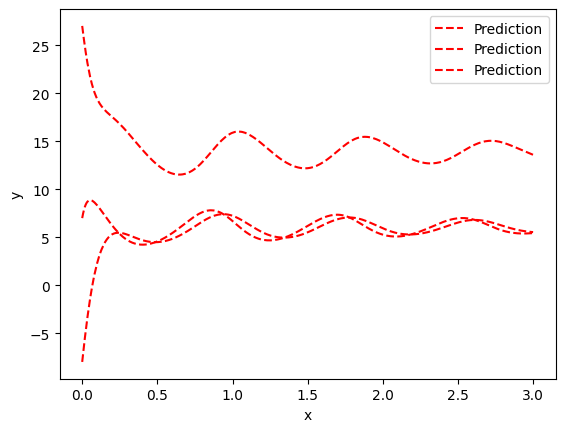

In [13]:
"""Backend supported: tensorflow.compat.v1, tensorflow, pytorch, jax"""
import deepxde as dde
import numpy as np


def gen_traindata():
    data = np.load("Lorenz.npz")
    return data["t"], data["y"]


C1 = dde.Variable(1.0)
C2 = dde.Variable(1.0)
C3 = dde.Variable(1.0)

# Most backends
def Lorenz_system(x, y):
    """Lorenz system.
    dy1/dx = 10 * (y2 - y1)
    dy2/dx = y1 * (15 - y3) - y2
    dy3/dx = y1 * y2 - 8/3 * y3
    """
    y1, y2, y3 = y[:, 0:1], y[:, 1:2], y[:, 2:]
    dy1_x = dde.grad.jacobian(y, x, i=0)
    dy2_x = dde.grad.jacobian(y, x, i=1)
    dy3_x = dde.grad.jacobian(y, x, i=2)
    return [
        dy1_x - C1 * (y2 - y1),
        dy2_x - y1 * (C2 - y3) + y2,
        dy3_x - y1 * y2 + C3 * y3,
    ]


def boundary(_, on_initial):
    return on_initial


geom = dde.geometry.TimeDomain(0, 3)

# Initial conditions
ic1 = dde.icbc.IC(geom, lambda X: -8, boundary, component=0)
ic2 = dde.icbc.IC(geom, lambda X: 7, boundary, component=1)
ic3 = dde.icbc.IC(geom, lambda X: 27, boundary, component=2)

# Get the train data
observe_t, ob_y = gen_traindata()
observe_y0 = dde.icbc.PointSetBC(observe_t, ob_y[:, 0:1], component=0)
observe_y1 = dde.icbc.PointSetBC(observe_t, ob_y[:, 1:2], component=1)
observe_y2 = dde.icbc.PointSetBC(observe_t, ob_y[:, 2:3], component=2)

data = dde.data.PDE(
    geom,
    Lorenz_system,
    [ic1, ic2, ic3, observe_y0, observe_y1, observe_y2],
    num_domain=400,
    num_boundary=2,
    anchors=observe_t,
)

net = dde.nn.FNN([1] + [40] * 3 + [3], "tanh", "Glorot uniform")
model = dde.Model(data, net)

external_trainable_variables = [C1, C2, C3]
variable = dde.callbacks.VariableValue(
    external_trainable_variables, period=600, filename="variables.dat"
)

# train adam
model.compile(
    "adam", lr=0.001, external_trainable_variables=external_trainable_variables
)
losshistory, train_state = model.train(iterations=20000, callbacks=[variable])

# train 2nd time with LBFGS
model.compile("L-BFGS", external_trainable_variables=external_trainable_variables)
losshistory, train_state = model.train(callbacks=[variable])

dde.saveplot(losshistory, train_state, issave=True, isplot=True)

# --------------------------------------------------------

## Neural ODEs

In [15]:
pip install torchdiffeq

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from torchdiffeq import odeint

### Learning a population dynamics

In [ ]:
#########################################Building the synthetic dataset
device = torch.device('cuda:' + str(args.gpu) if torch.cuda.is_available() else 'cpu')

true_y0 = torch.tensor([2.518629]).to(device)

t = torch.linspace(0., 1, 500).to(device)
t_test = torch.linspace(0., 1, 700).to(device)



class Lambda(nn.Module):

    def forward(self, t, y):
        return torch.mul(torch.mul(0.026, y), torch.sub(1, torch.div(y,12)))


with torch.no_grad():
    true_y = odeint(Lambda(), true_y0, t, method='dopri5')
    test_y = odeint(Lambda(), true_y0, t_test, method='dopri5')
########################################

class ODEFunc(nn.Module):

    def __init__(self):
        super(ODEFunc, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(1, 50),
            nn.Tanh(),
            nn.Linear(50,50),
            nn.ELU(),
            nn.Linear(50, 1),
        )

        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0, std=0.1)
                nn.init.constant_(m.bias, val=0)

    def forward(self, t, y):
        return self.net(y)

if __name__ == '__main__':

    func = ODEFunc().to(device)

    optimizer = optim.Adam(func.parameters(), lr=1e-5)

    for itr in range(1, 2001):
        pred_y = odeint(func, true_y0, t, method='rk4').to(device)
        loss = nn.MSELoss()(pred_y, true_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


        if itr % 1 == 0:
            with torch.no_grad():
                print('Iter {:04d} | MSE Loss {:.6f}'.format(itr, loss.item()))

                if itr == 2000:
                    pred_y_test = odeint(func, true_y0, t_test)
                    mse_t = nn.MSELoss()(pred_y_test, test_y)
                    print('MSE Loss {:.6f}'.format(mse_t.item()))
                    plt.plot(t_test.detach().cpu().numpy(), test_y.detach().cpu().numpy(), linestyle='dashed', label='real')
                    plt.plot(t_test.detach().cpu().numpy(), pred_y_test.detach().cpu().numpy(), label='predicted')
                    plt.xlabel("Time")
                    plt.ylabel("Population")
                    plt.legend()
                    plt.show()


Iter 0001 | MSE Loss 0.000784
Iter 0002 | MSE Loss 0.000770
Iter 0003 | MSE Loss 0.000755
Iter 0004 | MSE Loss 0.000741
Iter 0005 | MSE Loss 0.000727
Iter 0006 | MSE Loss 0.000713
Iter 0007 | MSE Loss 0.000699
Iter 0008 | MSE Loss 0.000686
Iter 0009 | MSE Loss 0.000672
Iter 0010 | MSE Loss 0.000659
Iter 0011 | MSE Loss 0.000646
Iter 0012 | MSE Loss 0.000633
Iter 0013 | MSE Loss 0.000620
Iter 0014 | MSE Loss 0.000607
Iter 0015 | MSE Loss 0.000595
Iter 0016 | MSE Loss 0.000582
Iter 0017 | MSE Loss 0.000570
Iter 0018 | MSE Loss 0.000558
Iter 0019 | MSE Loss 0.000546
Iter 0020 | MSE Loss 0.000535
Iter 0021 | MSE Loss 0.000523
Iter 0022 | MSE Loss 0.000512
Iter 0023 | MSE Loss 0.000501
Iter 0024 | MSE Loss 0.000490
Iter 0025 | MSE Loss 0.000479
Iter 0026 | MSE Loss 0.000468
Iter 0027 | MSE Loss 0.000458
Iter 0028 | MSE Loss 0.000447
Iter 0029 | MSE Loss 0.000437
Iter 0030 | MSE Loss 0.000427
Iter 0031 | MSE Loss 0.000417
Iter 0032 | MSE Loss 0.000408
Iter 0033 | MSE Loss 0.000398
Iter 0034 